# Load and Explore

In [ ]:
import pandas as pd
import numpy as np

df = "https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/Dataset/combined_air_quality_data.csv"
df = pd.read_csv(df)

print("jumlah baris dan kolom: ", df.shape)
display(df.head())

jumlah baris dan kolom:  (33879, 12)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51.0,Moderate,1.0,Good,36.0,Good,0.0,Good,51.0,Moderate
1,Brazil,Presidente Dutra,41.0,Good,1.0,Good,5.0,Good,1.0,Good,41.0,Good
2,Italy,Priolo Gargallo,66.0,Moderate,1.0,Good,39.0,Good,2.0,Good,66.0,Moderate
3,Poland,Przasnysz,34.0,Good,1.0,Good,34.0,Good,0.0,Good,20.0,Good
4,France,Punaauia,22.0,Good,0.0,Good,22.0,Good,0.0,Good,6.0,Good


# Eksplorasi dataset

In [ ]:
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33879 entries, 0 to 33878
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             33452 non-null  object 
 1   City                33878 non-null  object 
 2   AQI Value           33879 non-null  float64
 3   AQI Category        33879 non-null  object 
 4   CO AQI Value        33879 non-null  float64
 5   CO AQI Category     33879 non-null  object 
 6   Ozone AQI Value     33879 non-null  float64
 7   Ozone AQI Category  33879 non-null  object 
 8   NO2 AQI Value       33879 non-null  float64
 9   NO2 AQI Category    33879 non-null  object 
 10  PM2.5 AQI Value     33879 non-null  float64
 11  PM2.5 AQI Category  33879 non-null  object 
dtypes: float64(5), object(7)
memory usage: 3.1+ MB

Jumlah missing value di setiap kolom:
Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Val

# Data Cleaning

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\nMissing Values Before: ")
print(df.isnull().sum())

df['country'].fillna('Unknown', inplace=True)
df['city'].fillna('Unknown', inplace=True)

print("\nMissing Values After: ")
print(df.isnull().sum())

print("\nUkuran data setelah cleaning:", df.shape)
print("\nContoh data bersih:")
display(df.head())


Missing Values Before: 
country               427
city                    1
aqi_value               0
aqi_category            0
co_aqi_value            0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64

Missing Values After: 
country               0
city                  0
aqi_value             0
aqi_category          0
co_aqi_value          0
co_aqi_category       0
ozone_aqi_value       0
ozone_aqi_category    0
no2_aqi_value         0
no2_aqi_category      0
pm2.5_aqi_value       0
pm2.5_aqi_category    0
dtype: int64

Ukuran data setelah cleaning: (33879, 12)

Contoh data bersih:


/tmp/ipython-input-1285102595.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipython-input-1285102595.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,country,city,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51.0,Moderate,1.0,Good,36.0,Good,0.0,Good,51.0,Moderate
1,Brazil,Presidente Dutra,41.0,Good,1.0,Good,5.0,Good,1.0,Good,41.0,Good
2,Italy,Priolo Gargallo,66.0,Moderate,1.0,Good,39.0,Good,2.0,Good,66.0,Moderate
3,Poland,Przasnysz,34.0,Good,1.0,Good,34.0,Good,0.0,Good,20.0,Good
4,France,Punaauia,22.0,Good,0.0,Good,22.0,Good,0.0,Good,6.0,Good


# Cek Outlier

In [ ]:
print("\nMendeteksi Outlier menggunakan IQR:")

# Memilih kolom numerik untuk deteksi outlier
numerical_cols = df.select_dtypes(include=np.number).columns

outlier_count = 0
total_data_points = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mendeteksi outlier
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(col_outliers)
    outlier_count += num_outliers
    total_data_points += len(df[col])

    if num_outliers > 0:
        print(f"  Kolom '{col}': {num_outliers} outlier terdeteksi ({round((num_outliers / len(df[col])) * 100, 2)}% dari total data kolom ini)")
    else:
        print(f"  Kolom '{col}': Tidak ada outlier terdeteksi.")

print(f"\nTotal outlier terdeteksi di seluruh kolom numerik: {outlier_count} dari {total_data_points} data poin.")
if total_data_points > 0:
    print(f"Persentase total outlier: {round((outlier_count / total_data_points) * 100, 2)}%")
else:
    print("Tidak ada data poin untuk dianalisis.")


Mendeteksi Outlier menggunakan IQR:
  Kolom 'aqi_value': 767 outlier terdeteksi (2.26% dari total data kolom ini)
  Kolom 'co_aqi_value': 4676 outlier terdeteksi (13.8% dari total data kolom ini)
  Kolom 'ozone_aqi_value': 2876 outlier terdeteksi (8.49% dari total data kolom ini)
  Kolom 'no2_aqi_value': 3435 outlier terdeteksi (10.14% dari total data kolom ini)
  Kolom 'pm2.5_aqi_value': 569 outlier terdeteksi (1.68% dari total data kolom ini)

Total outlier terdeteksi di seluruh kolom numerik: 12323 dari 169395 data poin.
Persentase total outlier: 7.27%


# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print("Statistik deskriptif data numerik:\n")
display(df.describe())

print("\nStatistik deskriptif data kategorikal:\n")
display(df.select_dtypes(include='object').describe())

print("\nJumlah data per kategori AQI:")
display(df['aqi_category'].value_counts())

Statistik deskriptif data numerik:



,aqi_value,co_aqi_value,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value
count,33879.000000,33879.000000,33879.000000,33879.000000,33879.000000
mean,82.361820,3.786844,37.016133,6.027634,78.893803
std,56.230318,6.527357,34.796750,10.719042,54.557324
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,1.000000,19.000000,0.295508,42.013885
50%,63.000000,1.000000,30.000000,2.000000,62.000000
75%,105.421872,3.515097,40.990257,6.402679,101.734367
max,500.000000,133.000000,237.500000,103.119890,500.000000



Statistik deskriptif data kategorikal:



,country,city,aqi_category,co_aqi_category,ozone_aqi_category,no2_aqi_category,pm2.5_aqi_category
count,33879,33879,33879,33879,33879,33879,33879
unique,176,23465,6,6,6,4,6
top,Indonesia,Padang,Moderate,Good,Good,Good,Good
freq,10795,745,13894,27597,29560,33538,10208



Jumlah data per kategori AQI:


,count
aqi_category,
Moderate,13894
Good,10837
Unhealthy,5159
Unhealthy for Sensitive Groups,3084
Very Unhealthy,482
Hazardous,423


### Distribusi Kategori AQI

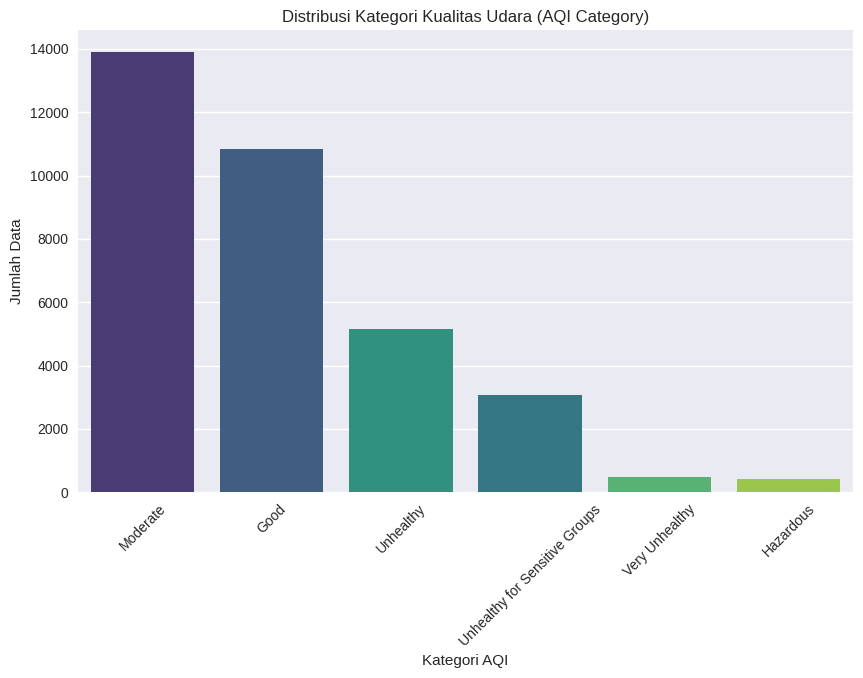

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='aqi_category', order=df['aqi_category'].value_counts().index, palette='viridis', hue='aqi_category', legend=False)
plt.title('Distribusi Kategori Kualitas Udara (AQI Category)')
plt.xlabel('Kategori AQI')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.show()

### Top 10 Negara dengan Kualitas Udara Terburuk (Rata-rata AQI Value Tertinggi)

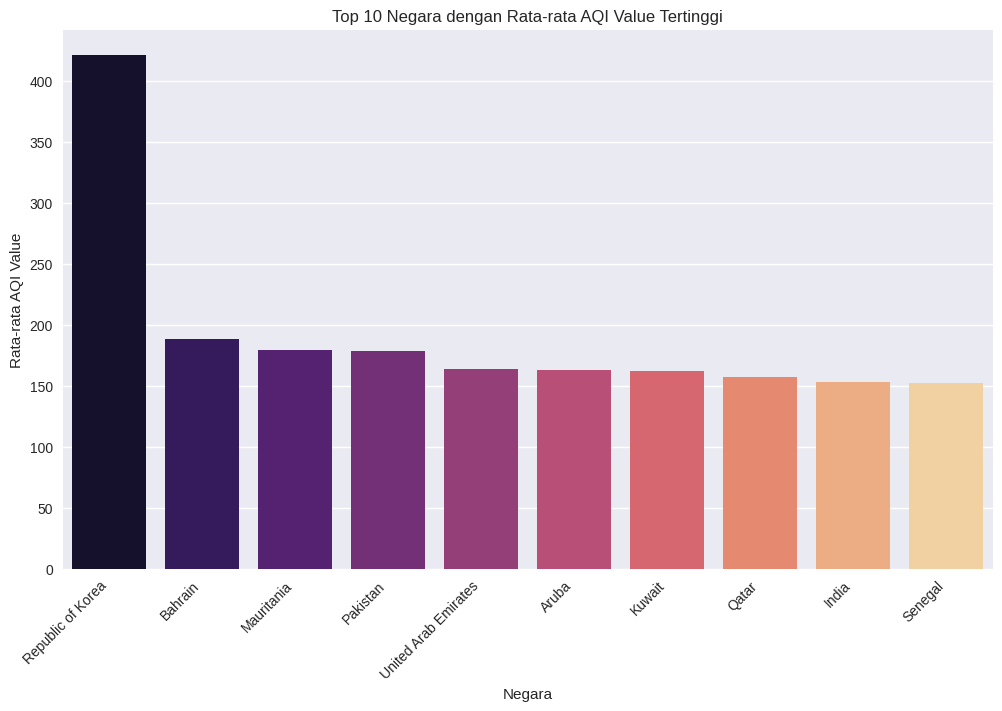

In [ ]:
top_countries_aqi = df.groupby('country')['aqi_value'].mean().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=top_countries_aqi, x='country', y='aqi_value', palette='magma', hue='country', legend=False)
plt.title('Top 10 Negara dengan Rata-rata AQI Value Tertinggi')
plt.xlabel('Negara')
plt.ylabel('Rata-rata AQI Value')
plt.xticks(rotation=45, ha='right')
plt.show()

# Model Training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']]
y = df['aqi_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (27103, 4)
Data test : (6776, 4)


## Regresi Linear

📈 Linear Regression Results:
Mean Absolute Error (MAE): 5.17
R² Score: 0.97

Cross-validation R² Scores: [np.float64(0.97), np.float64(0.969), np.float64(0.974), np.float64(0.97), np.float64(0.972)]
Mean CV R² Score: 0.971
Std Dev CV R² Score: 0.002


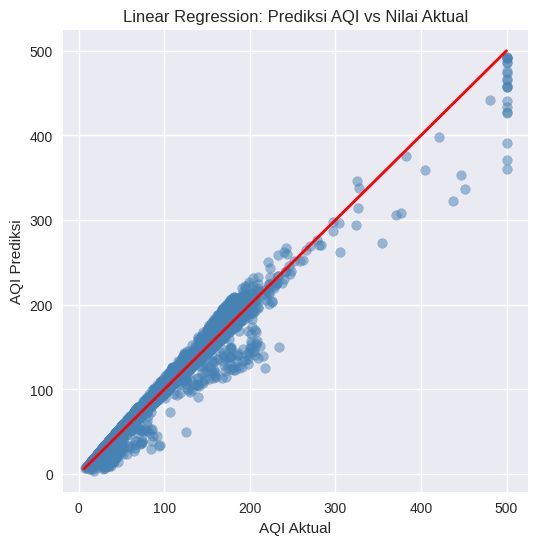

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("📈 Linear Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lr, 2))
print("R² Score:", round(r2_lr, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores])
print("Mean CV R² Score:", round(cv_scores.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Linear Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Random Forest

🌳 Random Forest Results:
Mean Absolute Error (MAE): 0.14
R² Score: 0.999

Cross-validation R² Scores: [np.float64(0.999), np.float64(0.998), np.float64(0.999), np.float64(0.998), np.float64(0.998)]
Mean CV R² Score: 0.999
Std Dev CV R² Score: 0.0


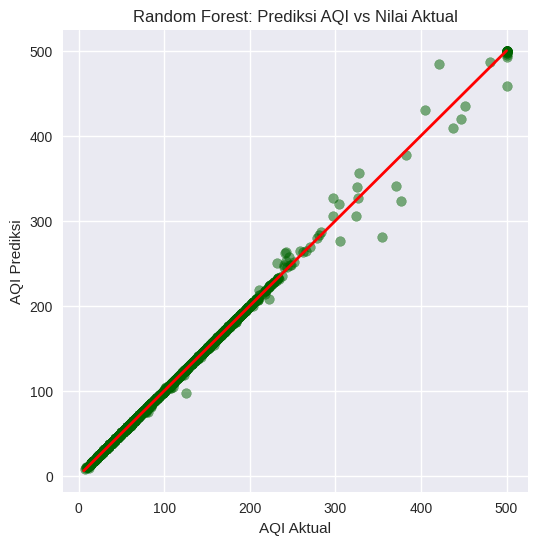

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌳 Random Forest Results:")
print("Mean Absolute Error (MAE):", round(mae_rf, 2))
print("R² Score:", round(r2_rf, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_rf])
print("Mean CV R² Score:", round(cv_scores_rf.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_rf.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Random Forest: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Decision Tree

🌲 Decision Tree Results:
MAE: 1.04
R² : 0.997

Cross-validation R² Scores: [np.float64(0.997), np.float64(0.996), np.float64(0.998), np.float64(0.997), np.float64(0.997)]
Mean CV R² Score: 0.997
Std Dev CV R² Score: 0.001


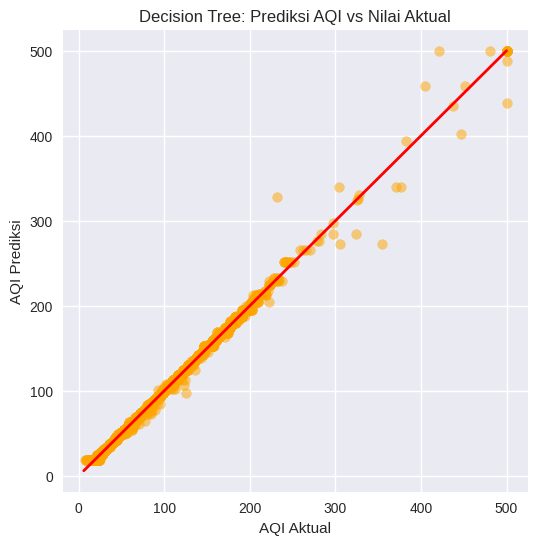

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score

dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("🌲 Decision Tree Results:")
print("MAE:", round(mae_dt, 2))
print("R² :", round(r2_dt, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_dt])
print("Mean CV R² Score:", round(cv_scores_dt.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_dt.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Decision Tree: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## K-Nearest Neighbors (K-NN)

👥 K-Nearest Neighbors Results:
MAE: 0.63
R² : 0.998

Cross-validation R² Scores: [np.float64(0.998), np.float64(0.999), np.float64(0.998), np.float64(0.997), np.float64(0.998)]
Mean CV R² Score: 0.998
Std Dev CV R² Score: 0.0


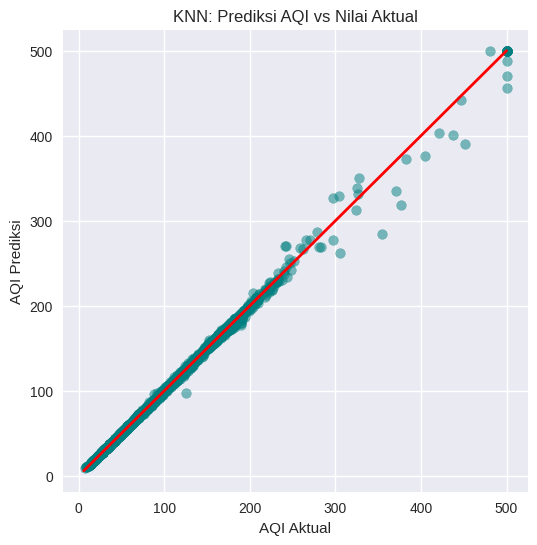

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("👥 K-Nearest Neighbors Results:")
print("MAE:", round(mae_knn, 2))
print("R² :", round(r2_knn, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_knn = cross_val_score(knn_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_knn])
print("Mean CV R² Score:", round(cv_scores_knn.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_knn.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("KNN: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Naive Bayes

☁️ Naive Bayes (Binned Regression) Results:
MAE: 39.63
R² : -0.668

Cross-validation R² Scores: [-0.668, -0.585, -0.609, -0.598, -0.533]
Mean CV R² Score: -0.599
Std Dev CV R² Score: 0.043

Cross-validation MAE Scores: [39.628, 39.293, 38.154, 38.932, 38.527]
Mean CV MAE Score: 38.907
Std Dev CV MAE Score: 0.526


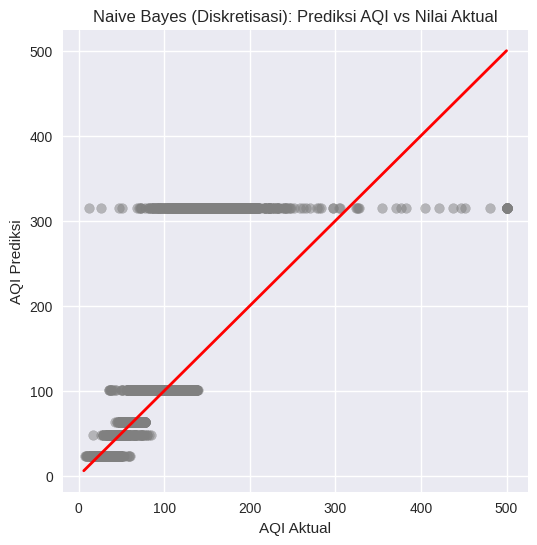

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
y_train_binned = discretizer.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_binned = discretizer.transform(y_test.values.reshape(-1, 1)).ravel()

nb_model = GaussianNB()
nb_model.fit(X_train, y_train_binned)

y_pred_nb_class = nb_model.predict(X_test)
# konversi balik ke nilai tengah tiap bin
y_pred_nb = discretizer.inverse_transform(y_pred_nb_class.reshape(-1, 1)).ravel()

mae_nb = mean_absolute_error(y_test, y_pred_nb)
r2_nb = r2_score(y_test, y_pred_nb)

print("☁️ Naive Bayes (Binned Regression) Results:")
print("MAE:", round(mae_nb, 2))
print("R² :", round(r2_nb, 3))

# Cross-validation for Naive Bayes (Binned Regression)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores_nb = []
cv_mae_scores_nb = []

for train_index, test_index in kf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    fold_discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    y_train_binned_fold = fold_discretizer.fit_transform(y_train_fold.values.reshape(-1, 1)).ravel()

    fold_nb_model = GaussianNB()
    fold_nb_model.fit(X_train_fold, y_train_binned_fold)

    y_pred_nb_class_fold = fold_nb_model.predict(X_test_fold)

    y_pred_nb_fold = fold_discretizer.inverse_transform(y_pred_nb_class_fold.reshape(-1, 1)).ravel()

    cv_r2_scores_nb.append(r2_score(y_test_fold, y_pred_nb_fold))
    cv_mae_scores_nb.append(mean_absolute_error(y_test_fold, y_pred_nb_fold))

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_r2_scores_nb])
print("Mean CV R² Score:", round(np.mean(cv_r2_scores_nb), 3))
print("Std Dev CV R² Score:", round(np.std(cv_r2_scores_nb), 3))

print("\nCross-validation MAE Scores:", [round(score, 3) for score in cv_mae_scores_nb])
print("Mean CV MAE Score:", round(np.mean(cv_mae_scores_nb), 3))
print("Std Dev CV MAE Score:", round(np.std(cv_mae_scores_nb), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_nb, alpha=0.5, color='gray')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Naive Bayes (Diskretisasi): Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## XGBoost

🚀 XGBoost Results:
Mean Absolute Error (MAE): 0.65
R² Score: 0.994

Cross-validation R² Scores: [np.float64(0.994), np.float64(0.99), np.float64(0.994), np.float64(0.991), np.float64(0.993)]
Mean CV R² Score: 0.993
Std Dev CV R² Score: 0.002


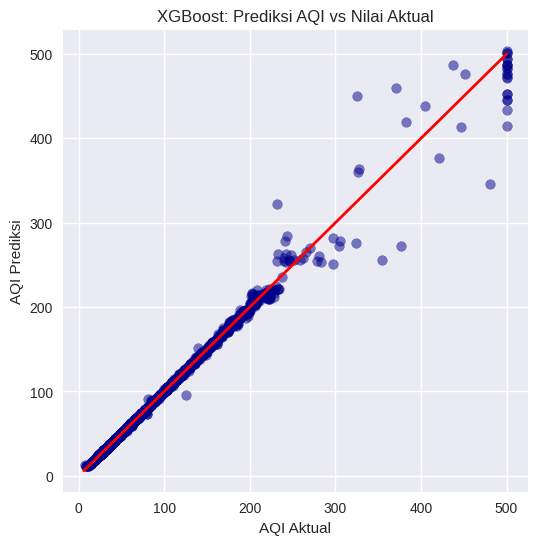

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("🚀 XGBoost Results:")
print("Mean Absolute Error (MAE):", round(mae_xgb, 2))
print("R² Score:", round(r2_xgb, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_xgb])
print("Mean CV R² Score:", round(cv_scores_xgb.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_xgb.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("XGBoost: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## LightBGM

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 27103, number of used features: 4
[LightGBM] [Info] Start training from score 82.269200
💡 LightGBM Results:
Mean Absolute Error (MAE): 0.46
R² Score: 0.998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 27103, number of used features: 4
[LightGBM] [Info] Start training from score 82.269200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001585 seconds.
You can set `for

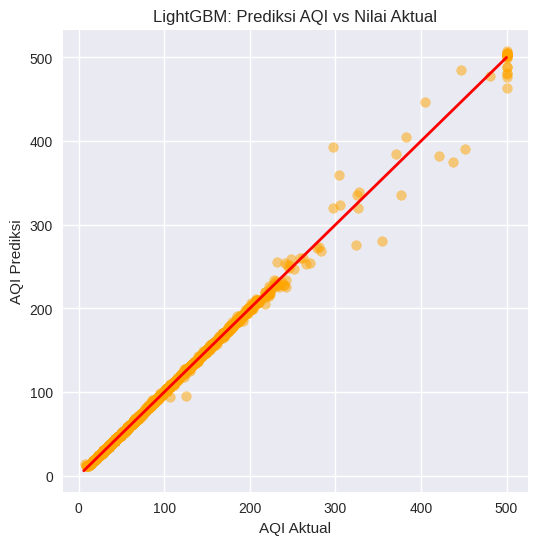

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("💡 LightGBM Results:")
print("Mean Absolute Error (MAE):", round(mae_lgbm, 2))
print("R² Score:", round(r2_lgbm, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lgbm = cross_val_score(lgbm_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_lgbm])
print("Mean CV R² Score:", round(cv_scores_lgbm.mean(), 3))
print("Std Dev CV R² Score:", round(np.std(cv_scores_lgbm), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("LightGBM: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Ridge Regression

🏔️ Ridge Regression Results:
Mean Absolute Error (MAE): 5.17
R² Score: 0.97

Cross-validation R² Scores (Ridge): [np.float64(0.97), np.float64(0.969), np.float64(0.974), np.float64(0.97), np.float64(0.972)]
Mean CV R² Score (Ridge): 0.971
Std Dev CV R² Score (Ridge): 0.002


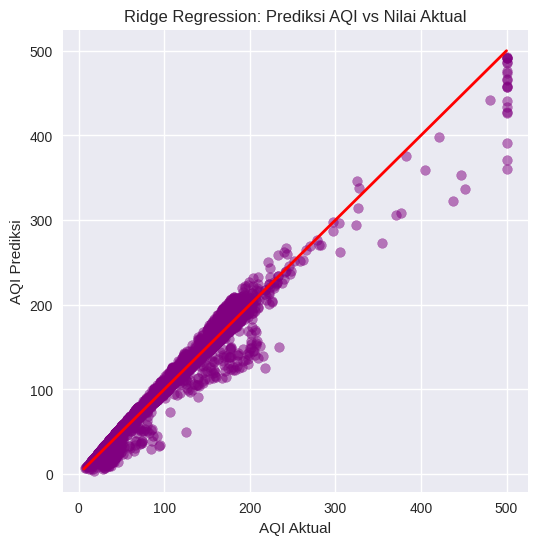

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("🏔️ Ridge Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_ridge, 2))
print("R² Score:", round(r2_ridge, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_ridge = cross_val_score(ridge_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Ridge):", [round(score, 3) for score in cv_scores_ridge])
print("Mean CV R² Score (Ridge):", round(cv_scores_ridge.mean(), 3))
print("Std Dev CV R² Score (Ridge):", round(cv_scores_ridge.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Ridge Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Lasso Regression


🪢 Lasso Regression Results:
Mean Absolute Error (MAE): 5.17
R² Score: 0.97

Cross-validation R² Scores (Lasso): [np.float64(0.97), np.float64(0.969), np.float64(0.974), np.float64(0.97), np.float64(0.972)]
Mean CV R² Score (Lasso): 0.971
Std Dev CV R² Score (Lasso): 0.002


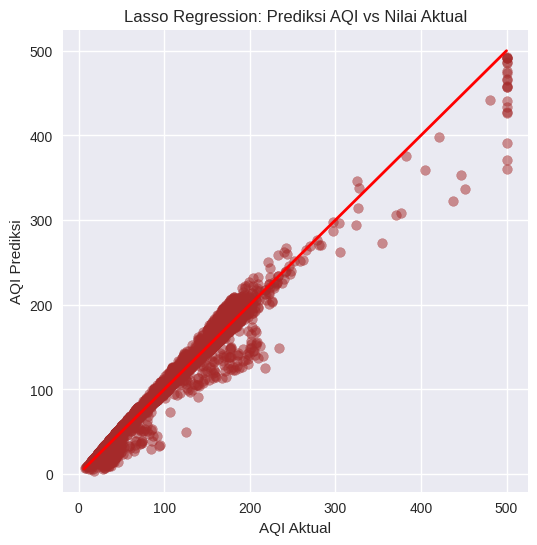

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n🪢 Lasso Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lasso, 2))
print("R² Score:", round(r2_lasso, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lasso = cross_val_score(lasso_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Lasso):", [round(score, 3) for score in cv_scores_lasso])
print("Mean CV R² Score (Lasso):", round(cv_scores_lasso.mean(), 3))
print("Std Dev CV R² Score (Lasso):", round(cv_scores_lasso.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='brown')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Lasso Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

## Boosting

🚀 Gradient Boosting Regressor Results:
Mean Absolute Error (MAE): 1.18
R² Score: 0.997

Cross-validation R² Scores (Gradient Boosting): [np.float64(0.997), np.float64(0.998), np.float64(0.998), np.float64(0.997), np.float64(0.997)]
Mean CV R² Score (Gradient Boosting): 0.997
Std Dev CV R² Score (Gradient Boosting): 0.0


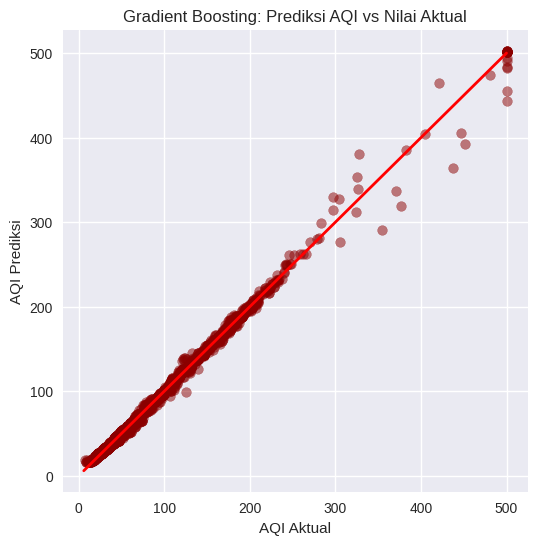

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("🚀 Gradient Boosting Regressor Results:")
print("Mean Absolute Error (MAE):", round(mae_gbr, 2))
print("R² Score:", round(r2_gbr, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gbr = cross_val_score(gbr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Gradient Boosting):", [round(score, 3) for score in cv_scores_gbr])
print("Mean CV R² Score (Gradient Boosting):", round(cv_scores_gbr.mean(), 3))
print("Std Dev CV R² Score (Gradient Boosting):", round(np.std(cv_scores_gbr), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.5, color='darkred')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Gradient Boosting: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

# Perbandingan tiap model

,Model,MAE,R² Score
1,Random Forest,0.141107,0.998869
6,LightGBM,0.459158,0.997884
3,KNN,0.628772,0.998444
5,XGBoost,0.652660,0.993914
2,Decision Tree,1.043841,0.997447
9,Gradient Boosting Regressor,1.181281,0.997443
8,Lasso Regression,5.168231,0.969657
7,Ridge Regression,5.169537,0.969655
0,Linear Regression,5.169537,0.969655
4,Naive Bayes,39.627849,-0.667925


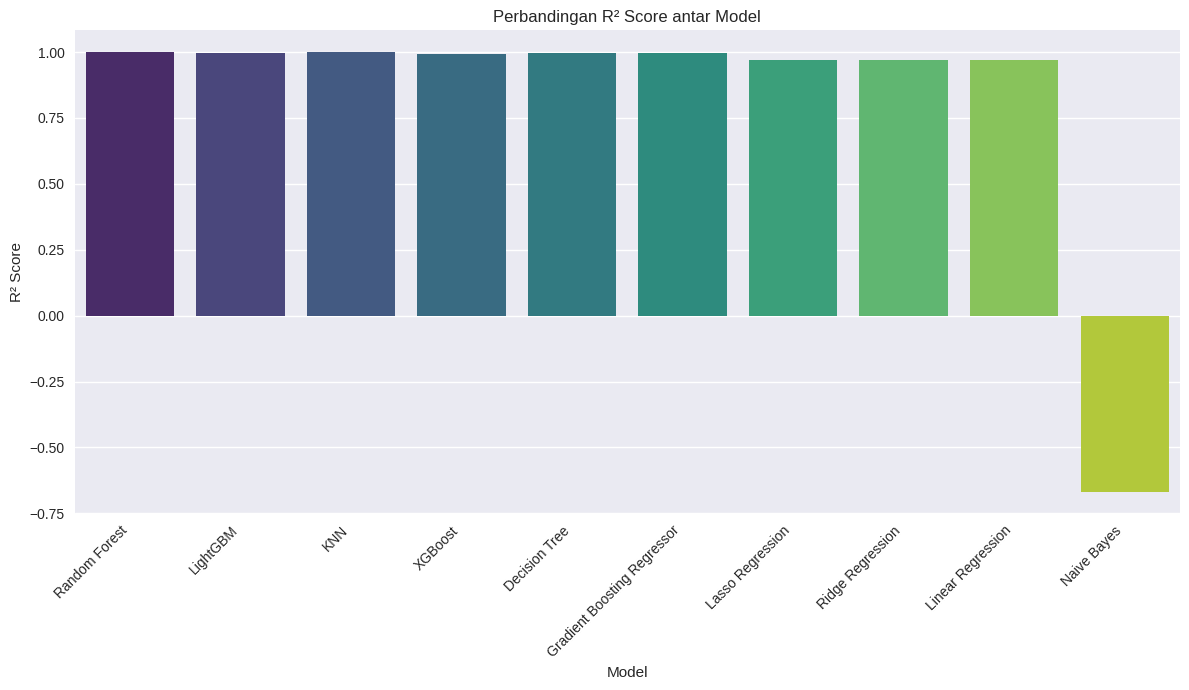

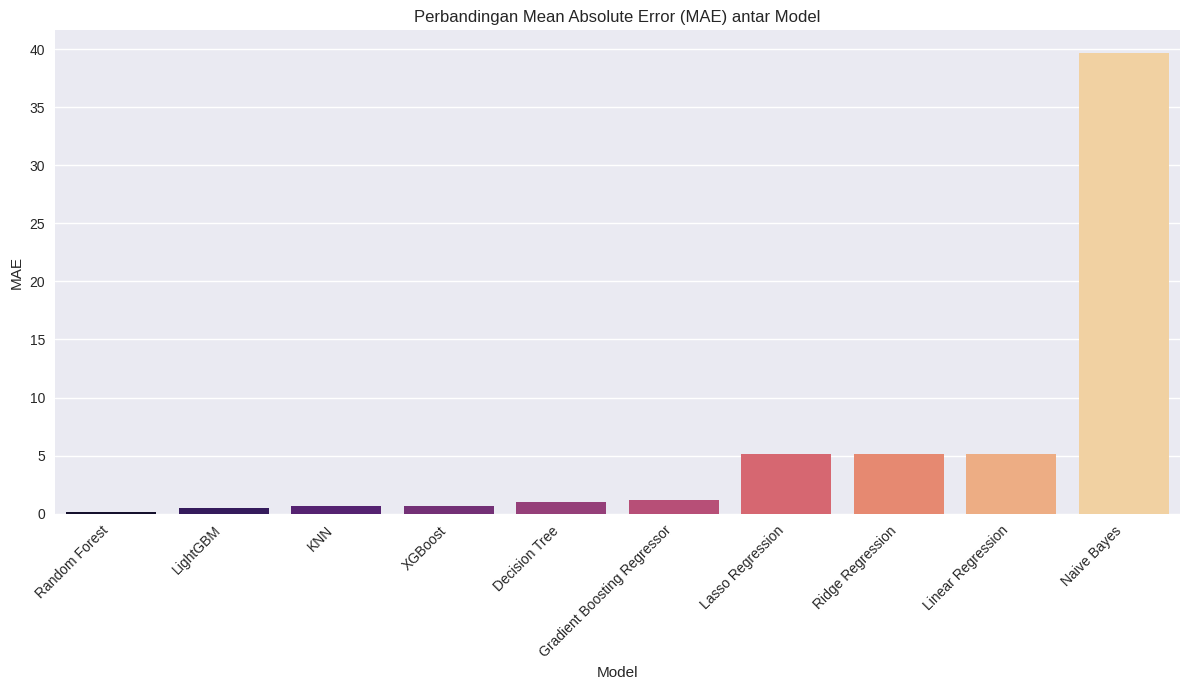

In [ ]:
models = [
    'Linear Regression',
    'Random Forest',
    'Decision Tree',
    'KNN',
    'Naive Bayes',
    'XGBoost',
    'LightGBM',
    'Ridge Regression',
    'Lasso Regression',
    'Gradient Boosting Regressor'
]
mae_scores = [
    mae_lr,
    mae_rf,
    mae_dt,
    mae_knn,
    mae_nb,
    mae_xgb,
    mae_lgbm,
    mae_ridge,
    mae_lasso,
    mae_gbr
]
r2_scores = [
    r2_lr,
    r2_rf,
    r2_dt,
    r2_knn,
    r2_nb,
    r2_xgb,
    r2_lgbm,
    r2_ridge,
    r2_lasso,
    r2_gbr
]

results_df = pd.DataFrame({
    'Model': models,
    'MAE': mae_scores,
    'R² Score': r2_scores
}).sort_values(by='MAE')

display(results_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Perbandingan R² Score antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MAE', data=results_df.sort_values(by='MAE', ascending=True), palette='magma', hue='Model', legend=False)
plt.title('Perbandingan Mean Absolute Error (MAE) antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

# Menyimpan model

In [ ]:
import joblib

joblib.dump(rf_model, "model_random_forest.pkl")

print("✅ Model Random Forest berhasil disimpan ke folder /content/ sebagai model_random_forest.pkl")

✅ Model Random Forest berhasil disimpan ke folder /content/ sebagai model_random_forest.pkl


# Uji Model

* Input User

In [ ]:
import joblib
import pandas as pd

# Load the best performing model (Random Forest)
try:
    loaded_rf_model = joblib.load("model_random_forest.pkl")
    print("✅ Model Random Forest berhasil dimuat.")
except FileNotFoundError:
    print("❌ Error: File model_random_forest.pkl tidak ditemukan. Pastikan model sudah disimpan.")
    loaded_rf_model = None # Set model to None if loading fails

if loaded_rf_model:
    # Function to get user input and make prediction
    def classify_aqi_from_input():
        print("\nMasukkan nilai polutan untuk prediksi AQI:")
        try:
            co_aqi = float(input("CO AQI Value (0 - 133): "))
            ozone_aqi = float(input("Ozone AQI Value (0 - 235): "))
            no2_aqi = float(input("NO2 AQI Value (0 - 91): "))
            pm25_aqi = float(input("PM2.5 AQI Value (0 - 500): "))

            # Create a DataFrame for the input
            input_data = pd.DataFrame([[co_aqi, ozone_aqi, no2_aqi, pm25_aqi]],
                                      columns=['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value'])

            # Predict the AQI value
            predicted_aqi = loaded_rf_model.predict(input_data)[0]
            print(f"\nNilai AQI Prediksi: {predicted_aqi:.2f}")

            # menentukan kategori AQI berdasarkan value dari standar EPA ranges
            if predicted_aqi <= 50:
                aqi_category = 'Good'
            elif predicted_aqi <= 100:
                aqi_category = 'Moderate'
            elif predicted_aqi <= 150:
                aqi_category = 'Unhealthy for Sensitive Groups'
            elif predicted_aqi <= 200:
                aqi_category = 'Unhealthy'
            elif predicted_aqi <= 300:
                aqi_category = 'Very Unhealthy'
            else:
                aqi_category = 'Hazardous'

            print(f"Kategori AQI Prediksi: {aqi_category}")

        except ValueError:
            print("Input tidak valid. Mohon masukkan angka.")
        except Exception as e:
            print(f"Terjadi kesalahan saat prediksi: {e}")

    # Run the classification function
    classify_aqi_from_input()

✅ Model Random Forest berhasil dimuat.

Masukkan nilai polutan untuk prediksi AQI:
CO AQI Value (0 - 133): 1
Ozone AQI Value (0 - 235): 34
NO2 AQI Value (0 - 91): 0
PM2.5 AQI Value (0 - 500): 20

Nilai AQI Prediksi: 34.00
Kategori AQI Prediksi: Good


* Uji data fetch (Real time)

In [ ]:
import requests
import time
import pandas as pd # Tambahkan import pandas
import joblib # Tambahkan import joblib

# Load the best performing model (Random Forest)
loaded_rf_model = None # Inisialisasi model di luar try-except
try:
    loaded_rf_model = joblib.load("model_random_forest.pkl")
    print("✅ Model Random Forest berhasil dimuat.")
except FileNotFoundError:
    print("❌ Error: File model_random_forest.pkl tidak ditemukan. Klasifikasi tidak dapat dilakukan.")


# Koordinat untuk Jakarta (sekitar pusat kota)
# Anda bisa menyesuaikannya jika perlu
latitude = -6.1818
longitude = 106.8223

# URL endpoint API Kualitas Udara OpenMeteo
# Pastikan URL ini adalah yang terbaru dan benar dari dokumentasi OpenMeteo
API_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Parameter permintaan data
# Pilih polutan yang Anda inginkan. Sesuaikan dengan kolom di dataset Anda
# agar bisa digunakan untuk prediksi dengan model yang sudah ada.
# Contoh: PM2.5, carbon_monoxide (CO), nitrogen_dioxide (NO2), ozone (O3)
params = {
    'latitude': latitude,
    'longitude': longitude,
    'current': 'pm2_5,carbon_monoxide,nitrogen_dioxide,ozone', # Polutan yang diminta
    'timezone': 'Asia/Jakarta' # Zona waktu
}

print(f"Memulai pengambilan data kualitas udara terkini untuk Jakarta ({latitude}, {longitude}) dari OpenMeteo dan klasifikasi...")

start_time = time.time()
duration = 10 # detik
interval = 2 # Ambil data setiap 2 detik

while time.time() - start_time < duration:
    try:
        # Hapus verify=False jika tidak diperlukan lagi dan masalah SSL sudah teratasi
        # Jika masih ada masalah SSL, tambahkan kembali verify=False DENGAN HATI-HATI
        response = requests.get(API_URL, params=params)
        response.raise_for_status() # Cek jika ada error HTTP (seperti 404)

        data = response.json()

        # Proses dan tampilkan data yang diterima
        if 'current' in data:
            current_data = data['current']
            print(f"\n--- Data Terkini ({time.strftime('%H:%M:%S')}) ---")
            print(f"  PM2.5: {current_data.get('pm2_5')} {data['current_units'].get('pm2_5')}")
            print(f"  CO: {current_data.get('carbon_monoxide')} {data['current_units'].get('carbon_monoxide')}")
            print(f"  NO2: {current_data.get('nitrogen_dioxide')} {data['current_units'].get('nitrogen_dioxide')}")
            print(f"  Ozone: {current_data.get('ozone')} {data['current_units'].get('ozone')}")

            # --- Integrasi dengan model prediksi Anda ---
            if loaded_rf_model is not None:
                try:
                    # Ekstrak nilai polutan yang dibutuhkan oleh model (sesuaikan nama kunci dan pastikan urutannya benar)
                    # OpenMeteo menggunakan μg/m³, model dilatih dengan nilai AQI.
                    # Perlu konversi jika model dilatih dengan unit yang berbeda.
                    # Untuk saat ini, kita asumsikan model bisa menerima nilai dalam unit ini atau perlu penyesuaian.
                    # Jika model Anda dilatih dengan nilai AQI, Anda perlu mengkonversi dari μg/m³ ke AQI
                    # menggunakan rumus standar EPA atau lookup table. Ini adalah bagian KRITIS.
                    # TANPA KONVERSI YANG TEPAT, PREDIKSI AKAN SALAH.
                    # Asumsi sementara: model bisa memproses nilai mentah ini (kemungkinan tidak akurat tanpa konversi)
                    # Atau, jika model dilatih dengan nilai AQI polutan individu, Anda perlu mencari cara
                    # mendapatkan nilai AQI individu dari OpenMeteo atau mengimplementasikan konversi.

                    # Untuk demonstrasi, kita akan menggunakan nilai mentah dari OpenMeteo.
                    # PASTIKAN NAMA KOLOM SESUAI dengan yang digunakan saat pelatihan model!
                    # OpenMeteo: pm2_5, carbon_monoxide, nitrogen_dioxide, ozone
                    # Model Anda: co_aqi_value, ozone_aqi_value, no2_aqi_value, pm2.5_aqi_value

                    # Coba petakan nama polutan:
                    co_val = current_data.get('carbon_monoxide', 0)
                    ozone_val = current_data.get('ozone', 0)
                    no2_val = current_data.get('nitrogen_dioxide', 0)
                    pm25_val = current_data.get('pm2_5', 0)

                    # Buat DataFrame untuk input model
                    input_for_model = pd.DataFrame([[co_val, ozone_val, no2_val, pm25_val]],
                                                  columns=['co_aqi_value', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']) # Sesuaikan nama kolom

                    # Prediksi nilai AQI total
                    predicted_aqi = loaded_rf_model.predict(input_for_model)[0]

                    # Tentukan kategori AQI berdasarkan prediksi (menggunakan rentang EPA)
                    if predicted_aqi <= 50:
                        aqi_category = 'Good'
                    elif predicted_aqi <= 100:
                        aqi_category = 'Moderate'
                    elif predicted_aqi <= 150:
                        aqi_category = 'Unhealthy for Sensitive Groups'
                    elif predicted_aqi <= 200:
                        aqi_category = 'Unhealthy'
                    elif predicted_aqi <= 300:
                        aqi_category = 'Very Unhealthy'
                    else:
                        aqi_category = 'Hazardous'

                    print(f"  Prediksi AQI Model: {predicted_aqi:.2f}")
                    print(f"  Kategori AQI Prediksi: {aqi_category}")

                except Exception as e:
                    print(f"Error saat memproses data atau prediksi dengan model: {e}")
            else:
                 print("\nModel Random Forest belum dimuat. Tidak dapat melakukan prediksi.")

        else:
            print(f"\n--- Data Terkini ({time.strftime('%H:%M:%S')}) ---")
            print("Data 'current' tidak ditemukan dalam respons API.")
            print("Respons API lengkap:", data)


    except requests.exceptions.RequestException as e:
        print(f"\nError mengambil data dari OpenMeteo API: {e}")
    except Exception as e:
        print(f"\nError tidak terduga: {e}")

    # Tunggu sebelum mengambil data lagi, jika durasi belum habis
    if time.time() - start_time < duration:
        time.sleep(interval)

print("\nSimulasi pengambilan data dan klasifikasi selesai.")

✅ Model Random Forest berhasil dimuat.
Memulai pengambilan data kualitas udara terkini untuk Jakarta (-6.1818, 106.8223) dari OpenMeteo dan klasifikasi...

--- Data Terkini (17:52:48) ---
  PM2.5: 34.9 μg/m³
  CO: 555.0 μg/m³
  NO2: 37.5 μg/m³
  Ozone: 10.0 μg/m³
  Prediksi AQI Model: 34.87
  Kategori AQI Prediksi: Good

--- Data Terkini (17:52:51) ---
  PM2.5: 34.9 μg/m³
  CO: 555.0 μg/m³
  NO2: 37.5 μg/m³
  Ozone: 10.0 μg/m³
  Prediksi AQI Model: 34.87
  Kategori AQI Prediksi: Good

--- Data Terkini (17:52:53) ---
  PM2.5: 34.9 μg/m³
  CO: 555.0 μg/m³
  NO2: 37.5 μg/m³
  Ozone: 10.0 μg/m³
  Prediksi AQI Model: 34.87
  Kategori AQI Prediksi: Good

--- Data Terkini (17:52:56) ---
  PM2.5: 34.9 μg/m³
  CO: 555.0 μg/m³
  NO2: 37.5 μg/m³
  Ozone: 10.0 μg/m³
  Prediksi AQI Model: 34.87
  Kategori AQI Prediksi: Good

Simulasi pengambilan data dan klasifikasi selesai.
